In [18]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [11]:
x = 6 * np.random.rand(200 ,1 ) - 3
y = 0.8 * x**2 + 0.9 * x + 2 + np.random.randn(200,1)

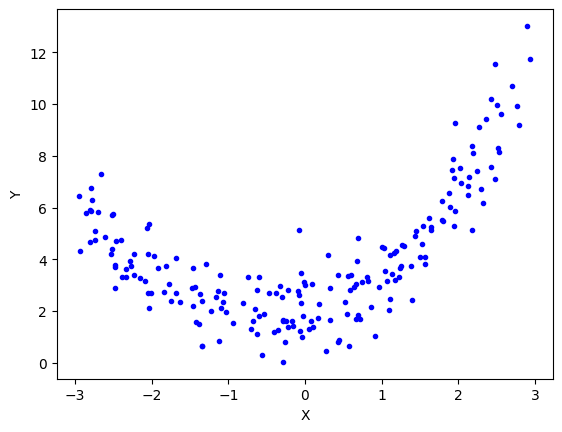

In [12]:
plt.plot(x,y,".b")
plt.xlabel('X')
plt.ylabel("Y")
plt.show()

In [15]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.15,random_state=43)

In [16]:
lr = LinearRegression()

In [19]:
lr.fit(x_train,y_train)
pred = lr.predict(x_test)

In [20]:
r2_score(y_test,pred)

0.19609428875739277

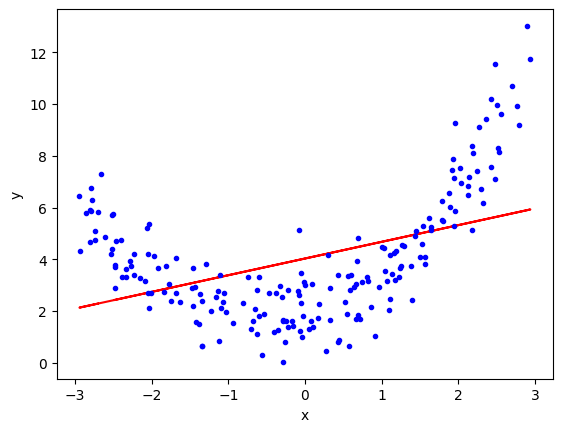

In [22]:
plt.plot(x_train,lr.predict(x_train),color= "r")
plt.plot(x,y,".b")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [24]:
poly = PolynomialFeatures(degree= 2)

x_train_trf = poly.fit_transform(x_train) 
x_test_trf = poly.transform(x_test)

In [37]:
x_train[0] ,x_train_trf[0],

(array([-2.47914105]), array([ 1.        , -2.47914105,  6.14614034]))

In [39]:
lr1 = LinearRegression()

In [43]:
lr1.fit(x_train_trf,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [44]:
pred2 = lr1.predict(x_test_trf)
r2_score(y_test,pred2)

0.8362891686631152

In [47]:
lr1.coef_ , lr1.intercept_

(array([[0.       , 0.8168639, 0.7755916]]), array([1.94036626]))

In [ ]:
x_new = np.linspace(-3,3,200).reshape(200,1)
x_new_poly = poly.transform(x_new)
y_new = lr.predict(x_new_poly)


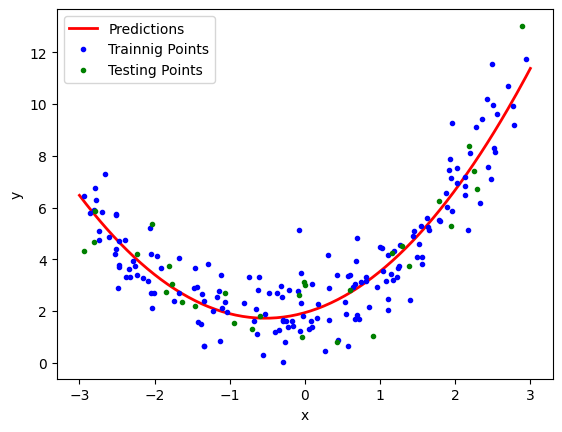

In [51]:
plt.plot(x_new,y_new,'r-',linewidth=2,label = "Predictions")
plt.plot(x_train,y_train,"b.",label="Trainnig Points")
plt.plot(x_test,y_test,"g.",label="Testing Points")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


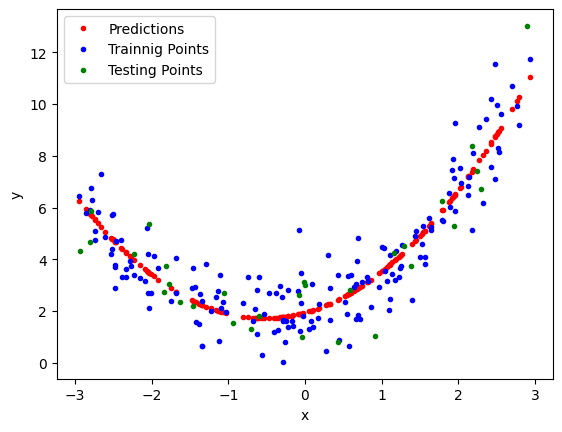

In [59]:
plt.plot(x_train,lr1.predict(x_train_trf),'r.',linewidth=2,label = "Predictions")
plt.plot(x_train,y_train,"b.",label="Trainnig Points")
plt.plot(x_test,y_test,"g.",label="Testing Points")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


In [ ]:
def Polynomial_fea(deg = 2):
    x_n = np.linspace(-3,3,100).reshape(100,1)
    x_n_poly = poly.transform(x_new)
    
    polybig_features =PolynomialFeatures(degree=deg)
    std = StandardScaler()
    lr2 = LinearRegression()
    poly_regg = Pipeline(
        [
            ("poly_features",polybig_features),
            ("standard_scaler",std),
            ("Linear_Regression",lr2)
        ]
    )
    
    poly_regg.fit(x,y)
    y_newbig = poly_regg.predict(x_n)
    plt.plot(x_n,y_newbig,"r",label="Degree"+ str(deg),linewidth=2)
    plt.plot(x_train,y_train,"b.",label="Trainnig Points")
    plt.plot(x_test,y_test,"g.",label="Testing Points")
    plt.xlabel("x") 
    plt.ylabel("y")
    plt.legend(loc="upper left")
    # plt.axis([-3,3,0,10])
    plt.show()

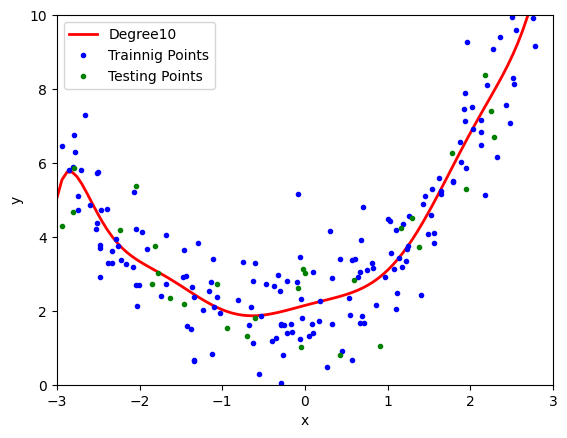

In [101]:
Polynomial_fea(10)

In [113]:
import numpy as np
import plotly.express as px

xx = 7 * np.random.rand(100, 1) - 2.8
yy = 7 * np.random.rand(100, 1) - 2.8

# FIX: Changed commas to plus signs and corrected variable names to xx and yy
zz = xx**2 + yy**2 + 0.2*xx + 0.2*yy + 0.1*xx*yy + 2 + np.random.randn(100, 1)

fig = px.scatter_3d(x=xx.ravel(), y=yy.ravel(), z=zz.ravel())
fig.update_layout(margin=dict(l=0, r=0, b=0, t=0))
fig.show()


In [120]:
lr_3d = LinearRegression()
lr_3d.fit(np.array([xx,yy]).reshape(100,2),zz)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [121]:
x_input = np.linspace(xx.min(),xx.max(),10)
y_input = np.linspace(yy.min(),yy.max(),10)
xGrid,yGrid = np.meshgrid(x_input,y_input)

final  = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T

z_final = lr_3d.predict(final).reshape(10,10)


In [123]:
import plotly.graph_objects as go
fig = px.scatter_3d(x=xx.ravel(), y=yy.ravel(), z=zz.ravel())
fig.update_layout(margin=dict(l=0, r=0, b=0, t=0))
fig.add_trace(go.Surface(x=x_input,y=y_input,z=z_final))
fig.show()

In [124]:
x_multi = np.array([xx,yy]).reshape(100,2)

In [125]:
x_multi.shape

(100, 2)

In [142]:
poly = PolynomialFeatures(degree=10)
x_multi_trans = poly.fit_transform(x_multi)

In [143]:
# poly.n_features_in_,poly.n_output_features_,poly.powers_

In [144]:
lr4 =LinearRegression()

In [145]:
lr4.fit(x_multi_trans,zz)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [146]:
z_final =lr4.predict(x_multi_trans).reshape(10,10)

In [147]:
fig = px.scatter_3d(x=xx.ravel(), y=yy.ravel(), z=zz.ravel())
fig.update_layout(margin=dict(l=0, r=0, b=0, t=0))
fig.add_trace(go.Surface(x=x_input,y=y_input,z=z_final))
fig.show()